# Notebook 3: Building up to quantum cellular automata - Semiclassical cellular automata

Roadplan:
- Building up Markov transition matrices
- Study of Markov transition matrices
- Change dynamics function so that it uses a probabilistic approach for the cells given or the entire lattice.
- Look at other function to change
- Plot some classical vs semiclassical
- Extending markov chains to semiclassical automata

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# From Notebook 1

from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

In [3]:
# From Notebook 2
from Functions_for_Notebook_2 import plot_grid_multiple, plot_multiple_cells #To grid multiple systems

from Functions_for_Notebook_2 import is_rule

from Functions_for_Notebook_2 import is_reversible, gardens_of_eden

## 1. Building up Markov Transition Matrices
https://www.youtube.com/watch?v=Hmzfv9dqw94

https://www.youtube.com/watch?v=i3AkTO9HLXo&list=PLM8wYQRetTxBkdvBtz-gw8b9lcVkdXQKV

General markov chains have the characteristic that the future state only depends on the current state and the probabilities of all posssible subsequent states add up to one (just like elementary CA).

Therefore, a transition matrix can be computed for the evolution of CA system, dependent on the rule and lattice length:

In [ ]:
def next_state(state,rule_number, L): #This code come up often, so better to automate it  
        result = []
        rule = make_rule(rule_number) 
        for i in range(L):
            left   = str(int(state[-1][i - 1])) if i > 0 else '0'       # zero boundary
            center = str(int(state[-1][i]))
            right  = str(int(state[-1][i + 1])) if i < L - 1 else '0'   # zero boundary
            neighbourhood = left + center + right
            result.append(rule[neighbourhood])
        return tuple(result)

In [ ]:
def markov_matrix(rule_number: int, L: int):
    import itertools

    rule = make_rule(rule_number)  
    all_states = list(itertools.product([0, 1], repeat=L))

    state_labels = [''.join(str(b) for b in s) for s in all_states]
    print(f"\nTransition matrix — Rule {rule_number}, L={L}")
    print(f"Row = current state   Col = next state\n")
    print("       " + "  ".join(state_labels))
    print("      " + "---" * len(all_states))

    for state in all_states:
        nxt = next_state(state, rule, L)
        row = "  ".join("1" if col == nxt else "0" for col in all_states)
        label = ''.join(str(b) for b in state)
        print(f"{label}  |  {row}") # Visual representation, good for seeing how it is structured
        # Need to make it print out an array to perform product with vector

print(markov_matrix(4, 4 ))


Transition matrix — Rule 4, L=4
Row = current state   Col = next state

       0000  0001  0010  0011  0100  0101  0110  0111  1000  1001  1010  1011  1100  1101  1110  1111
      ------------------------------------------------


TypeError: '<=' not supported between instances of 'int' and 'dict'

### Proving the function works:

## 2. Study of Markov Transition Matrices

## 3. Adjusting previous functions to account for a probabilistic approach
### 1.1) Dynamics function

First, we define a function for probablistic approaches and see if it can be tirned into a generalization of the previous dynamics function.

Firstly, define a new function that for the initial conditions has an associated list with the probability that it is one, then add an option such that if only one value is put in for the probabilities, then that probability applied for all initial conditions. We can also define it such that if no probabilities are specified, the function reverts back to its classical version. 

In [4]:
def probabilistic_dynamics(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(probabilistic_dynamics(3, 9, [], None , 9))
print(probabilistic_dynamics(3, 9, [1,2,3], [0.3,0.6,0.7] , 9))

[[1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]]
[[1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 1 0]
 [1 1 1 1 1 0 0 0 1]
 [0 0 0 0 0 1 1 0 0]
 [1 1 1 1 0 0 0 1 1]
 [0 0 0 0 1 1 0 0 0]
 [1 1 1 0 0 0 1 1 1]
 [0 0 0 1 1 0 0 0 0]
 [1 1 0 0 0 1 1 1 1]
 [0 0 1 1 0 0 0 0 0]]


To prove it works, we can prove it in different steps: 

1. The semiclassical arrays for the case where the probability is zero must match the classical dynamics that don't include the value for which the probabolity is zero as an initial starting point in the first place.

In [5]:
np.allclose(probabilistic_dynamics(23, 10, [1,2,3, 4], [1,1,1, 0], 10), dynamics(23, 10, [1,2,3], 10))

np.allclose(probabilistic_dynamics(23, 1000, [1,20,33, 4], [1,1,1, 0], 1000), dynamics(23, 1000, [1,20,33], 1000))



True

2. The absolute same function can give different results and will most likely for a large number of initial conditions

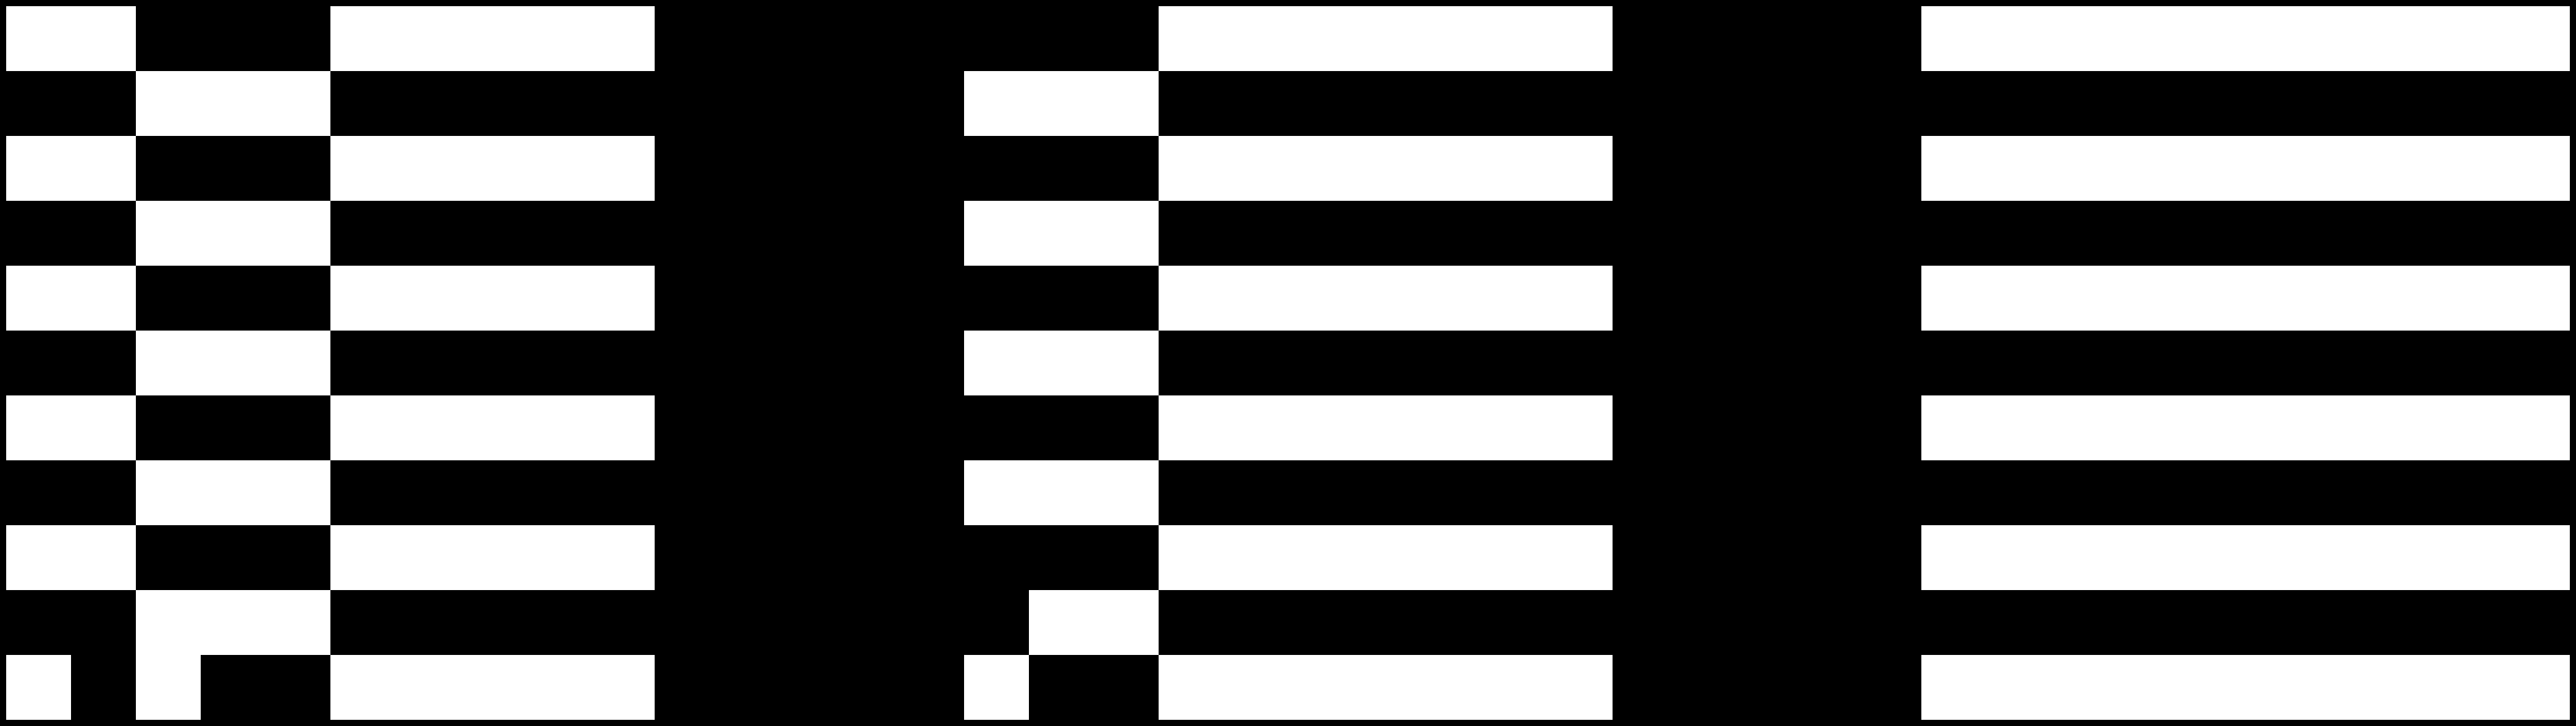

In [9]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10)], cols=3)

### 1.2) Other functions

## 2. Plotting rules against their semiclassical counterparts
Comparing the evolution of semiclassical systems to their purely classical counterparts.

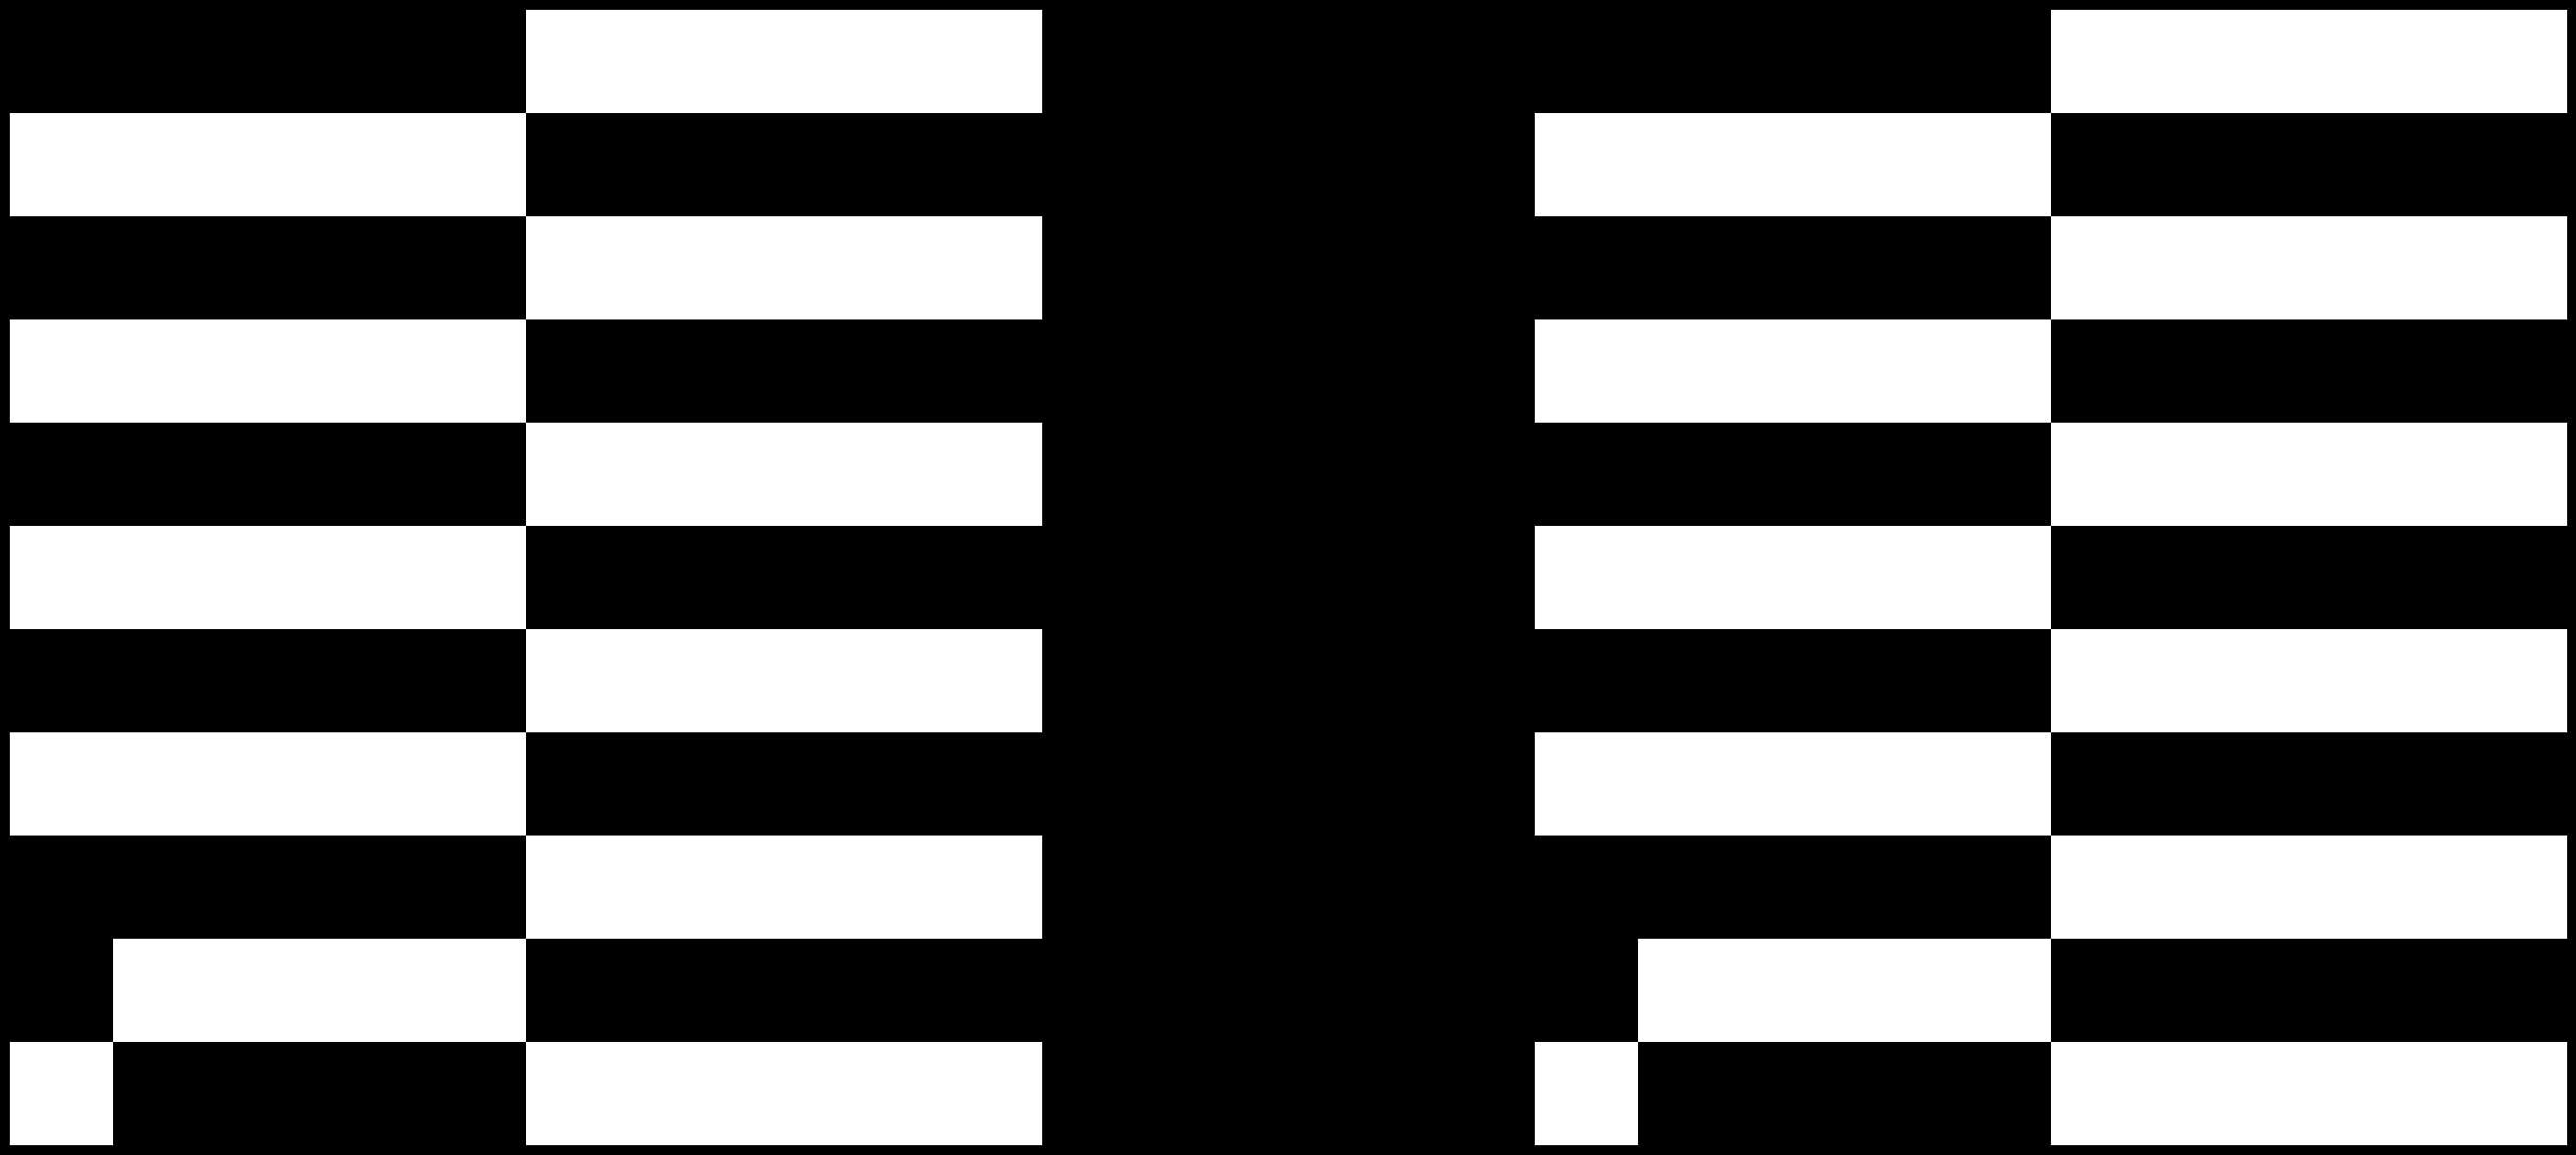

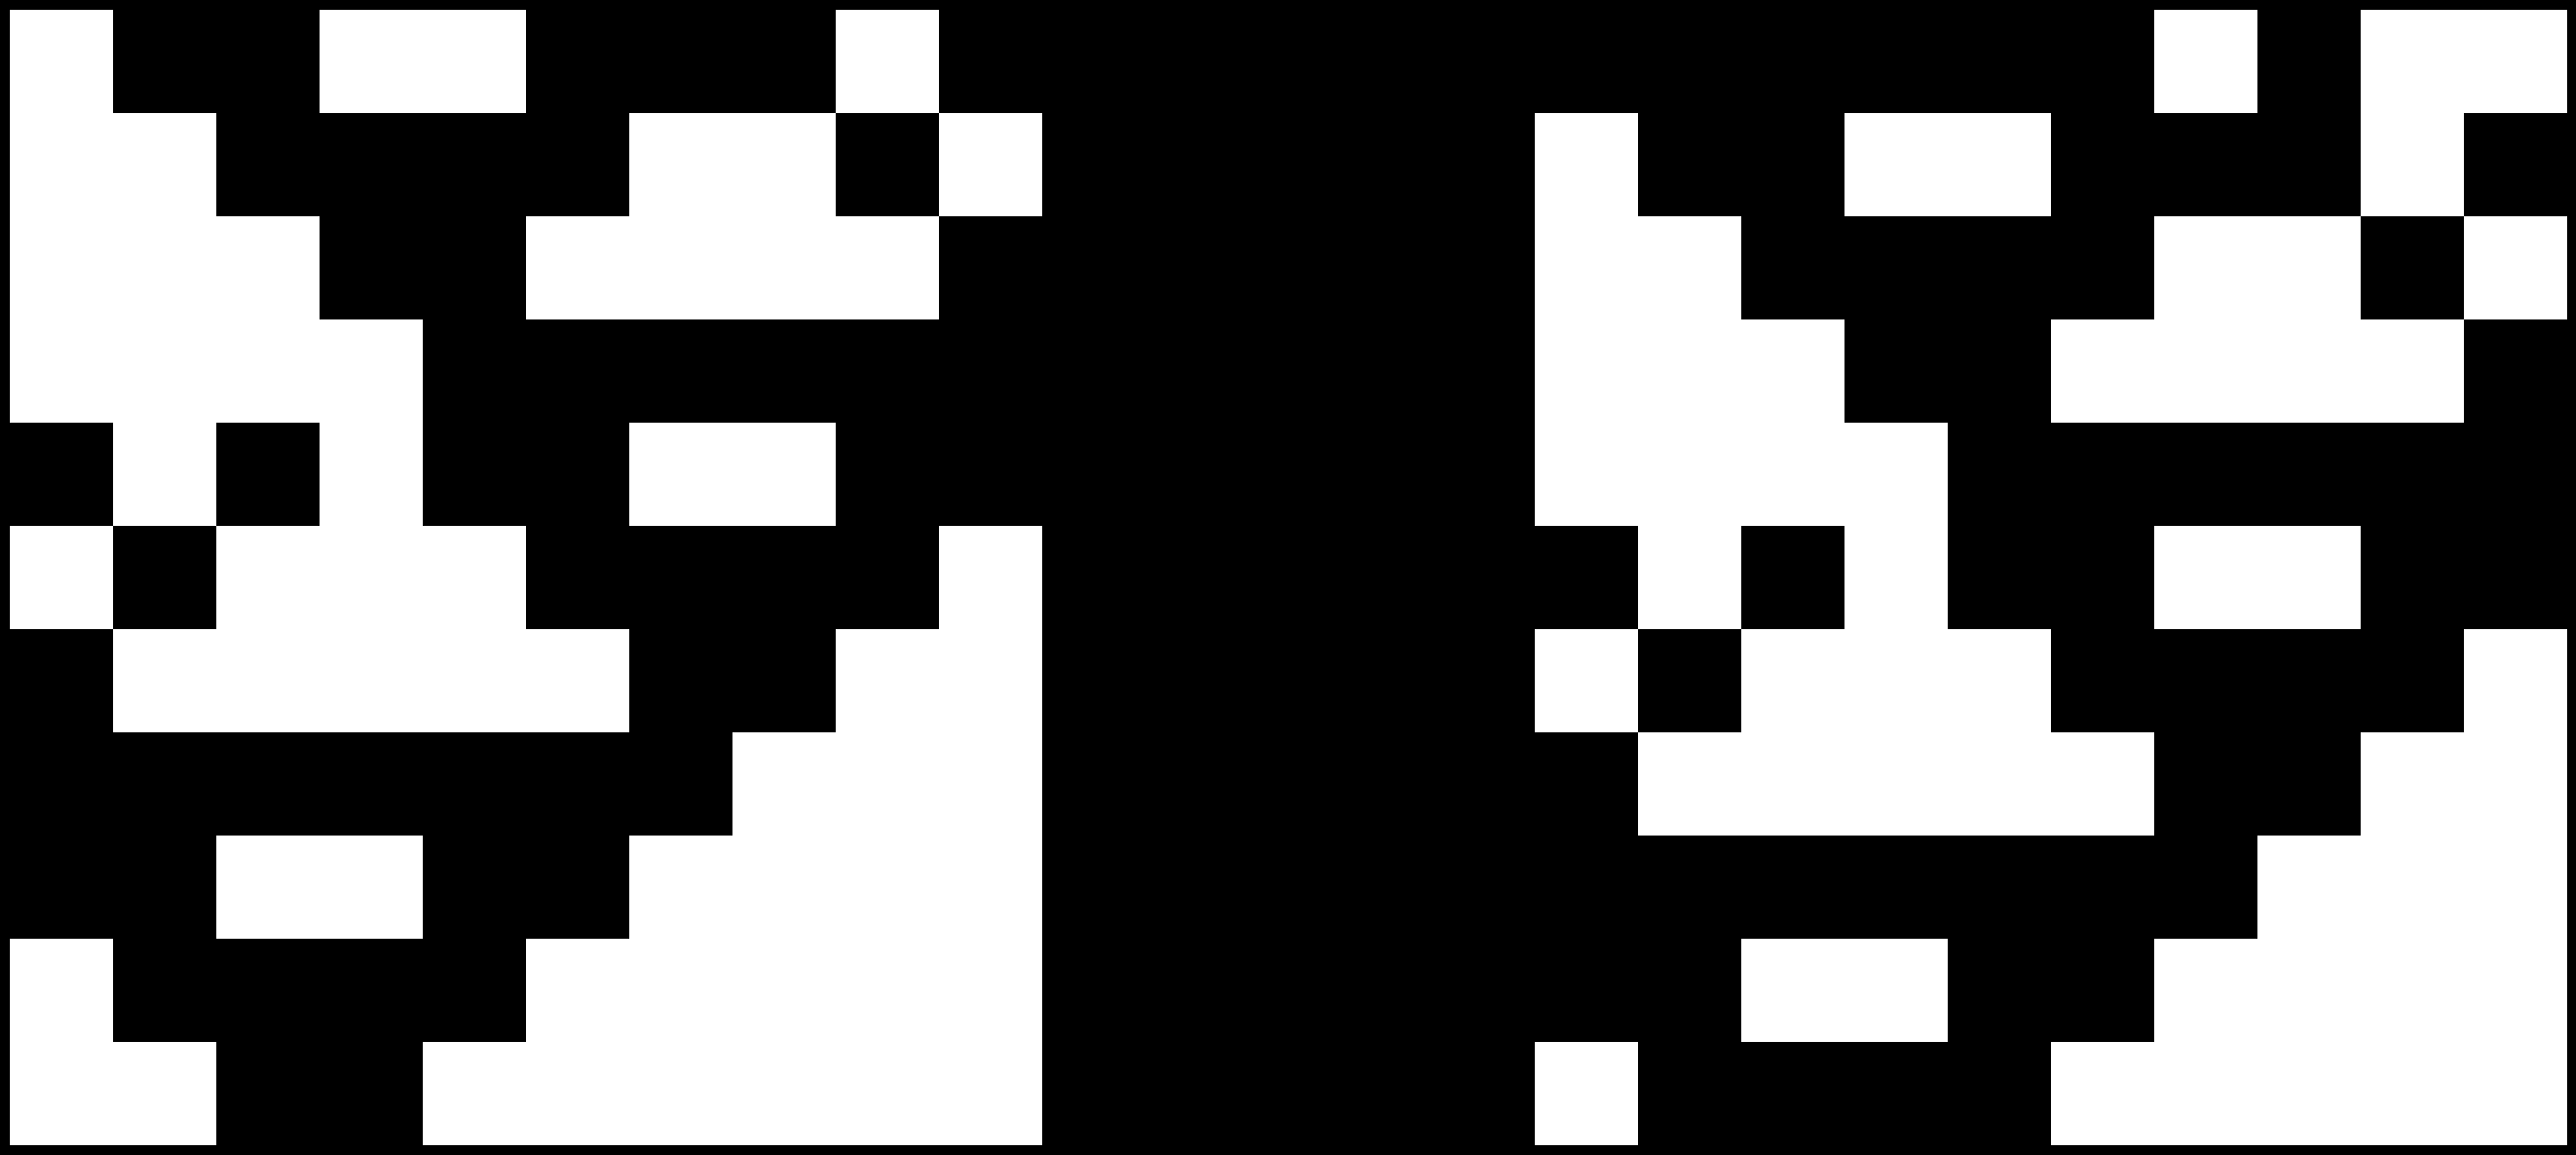

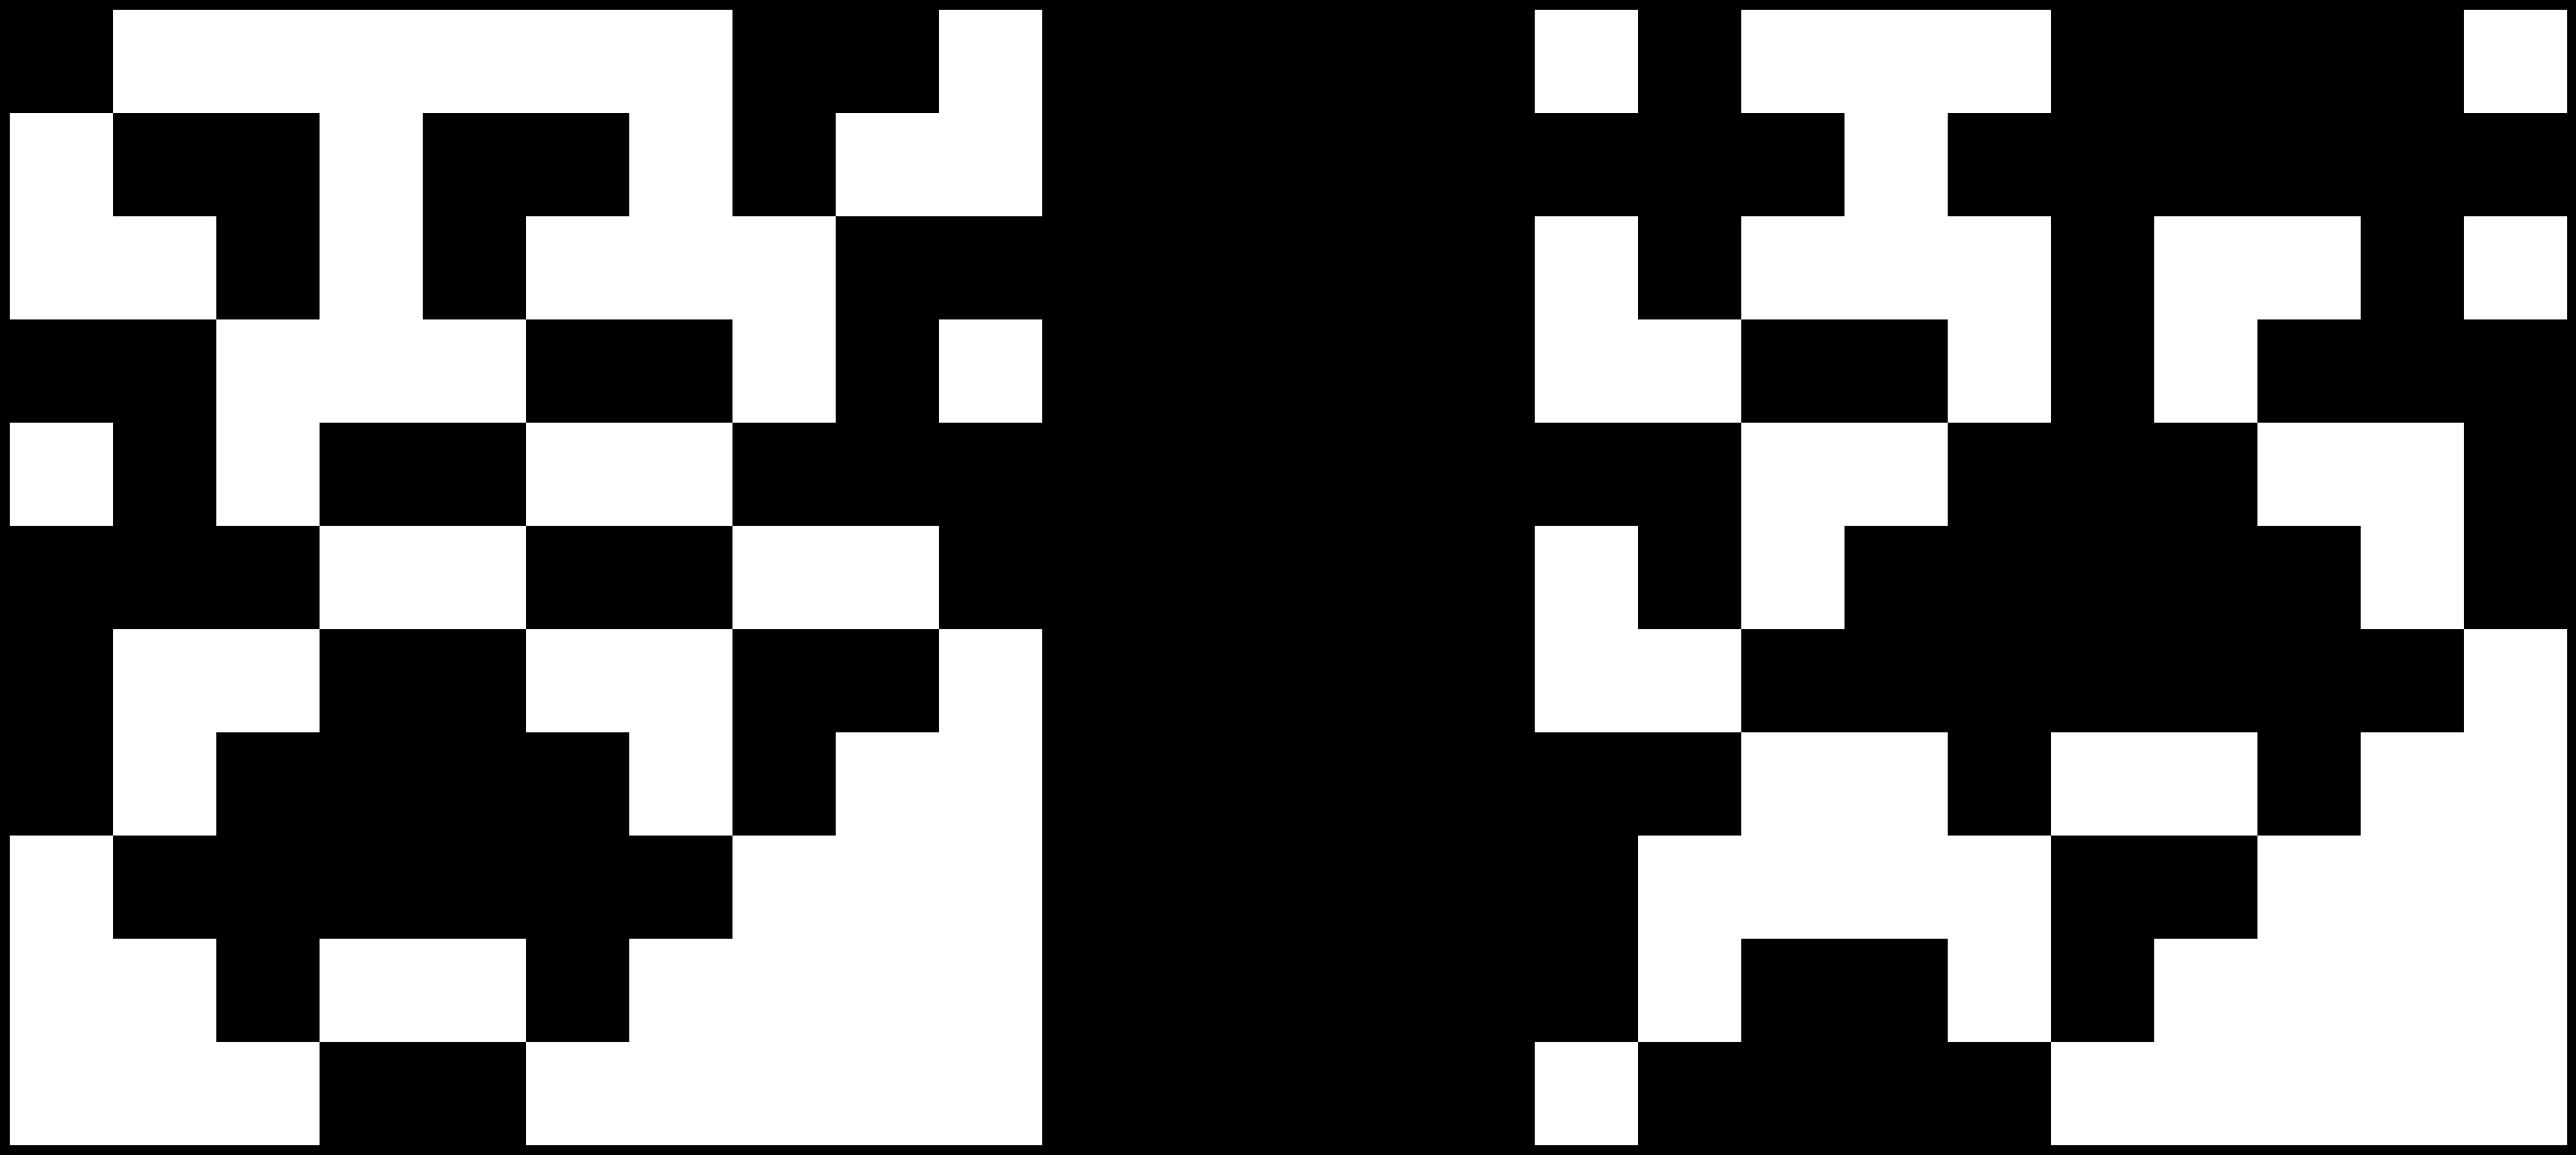

In [14]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(23, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(90, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(90, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(150, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(150, 10, [1,2,3,4], 10)], cols=3)

## Behaviour of semiclassical cellular automata and comparison with classical CA